In [1]:
!pip install langgraph
!pip install groq langgraph langchain-groq
!pip install python-dotenv
!pip install groq
!pip install numpy
!pip install matplotlib

In [87]:
from typing import TypedDict, List,Union,Annotated,Sequence,Dict
from langchain_core.messages import HumanMessage ,AIMessage,BaseMessage,ToolMessage,SystemMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
import os
from dotenv import load_dotenv
import numpy as np
from pydantic import BaseModel
from groq import Groq
from langchain_groq import ChatGroq
import json
import scipy

In [137]:
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

llm1 = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY_1"),
    model="llama-3.1-8b-instant",
)

llm2 = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY_2"),
    model="llama-3.1-8b-instant",
)

llm3 = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY_3"),
    model="llama-3.1-8b-instant",
)
llm4 = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY_4"),
    model="llama-3.1-8b-instant",
)
llm5 = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY_5"),
    model="llama-3.1-8b-instant",
)
llms=[llm1,llm2,llm3,llm4,llm5]
# "gpt-oss-20b"
from groq import RateLimitError

In [138]:
from typing import Annotated
from typing_extensions import TypedDict

# def merge_bid_history(left, right):
#     print("LEFT:", {k: len(v) for k, v in left.items()})
#     print("RIGHT:", {k: len(v) for k, v in right.items()})
#     merged = {k: v[:] for k, v in left.items()}

#     for player, bids in right.items():
#         merged.setdefault(player, []).extend(bids)
   
#     return merged

def merge_current_bids(left, right):
    if right is None:
        return {}
    merged = left.copy()
    merged.update(right)   # each agent contributes one key
    return merged

In [25]:
import time
from groq import RateLimitError

def invoke_with_retry(messages,agent_number,max_retries=7):
    delay = 2
    llm = llms[agent_number % len(llms)]
    for attempt in range(max_retries):
        try:
            return llm.invoke(messages)

        except RateLimitError:
            if attempt == max_retries - 1:
                raise

            print(f"Rate limit hit. Retrying in {delay} seconds...")
            time.sleep(delay)
            delay *= 2

In [ ]:
# To implement :
# Shuffle order
# History Text 
# Modify rules
# run_game and run round modification

In [139]:
class AgentState(TypedDict):
        bid_history: Dict[str,List[int]]
        current_bids: Annotated[Dict[str, Dict[str, Union[int,str]]],merge_current_bids] 
        gossip_bid_storage : Dict[str, Dict[str, Union[int,str]]]
        Eliminated_players: Dict[str, int] | None
        Points_remaining:Dict[str, int] | None
        round_number: int | None
        sub_round_number:int | None
        threshold:int | None
        threshold_increment : int | None
        Active_players:List[str] 
        Rules: str | None
        Game_over: bool | None


In [140]:
#Common prompt for all agents
# memory = false
from pydantic import ConfigDict


from pydantic import ConfigDict

def rules(number_of_players):
    Rules_without_memory = f"""You are participating in a bidding game consisting of up to 10 rounds with {number_of_players} players.

    You begin the game with a total budget of 500 points. Every round, each active player submits a bid.

    The threshold is known and will be provided.

    At the end of each round:

    * Any player whose bid is below the threshold is considered vulnerable.
    * Among vulnerable players, the player(s) with the lowest bid are eliminated.
    * If multiple players are tied for the lowest bid below the threshold, all such players are eliminated.
    * Players whose bids are above or equal to the threshold survive the round.

    The game ends when:

    * Only one player remains, or
    * All 10 rounds have been completed.

    If multiple players remain after Round 10, the winner is the surviving player with the greatest number of points remaining. Therefore, conserving points is important even if you survive.

    You will be provided with:

    * The current round number.
    * The threshold value.
    * Your remaining points.
    * Previous Bid you made.

    Your objective is to maximize your chance of winning the game.

    To do this, you must:

    * Survive each round.
    * Avoid unnecessary spending.
    * Preserve as many points as possible for later rounds.
    * If multiple players survive to the end of Round 10, you must try to have more remaining points than the other survivors.

    You have a limited budget of 500 points that must last across multiple rounds. Running out of points will eliminate you, so consider both immediate survival and future rounds when deciding how many points to bid.
    
    You may also be given opportunities to listen to other agents bids, in which you will be provided your previous bid along with another agent's bid and their respective confidences in their bids.
    You must try to update your bids by observing their bids to arrive at a better bid. 
    """
    return Rules_without_memory





In [141]:
def setup(state:AgentState)->AgentState:
    state["Rules"] = rules(len(state["Active_players"]))
    state["gossip_bid_storage"]={x: {} for x in state["Active_players"]}
    state["round_number"] = 1
    state["sub_round_number"]=0
    state["threshold"] = 30
    state["threshold_increment"] = 3
    state["bid_history"] = {x: [] for x in state["Active_players"]}
    state["Points_remaining"] = {x: 500 for x in state["Active_players"]}
    state["Game_over"] = False
    state["Eliminated_players"] = dict()
    return state

def run_game(state:AgentState)->AgentState:
    if state["round_number"] > 10 or len(state["Active_players"]) <= 1:

        print("Game Concluded.")
        if len(state["Active_players"]) == 1:
            print(f"Winner: {state['Active_players'][0]}" )
        elif len(state["Active_players"]) == 0:
            print( "No winner, all players eliminated.")
        else:
            print("Surviving Players:")
            for agent_ in state["Active_players"]:
                print(agent_)
            
        return {"Game_over": True }
    else:
        print(f"\n\nRound {state['round_number']} begins.\nCurrent threshold: {state['threshold']}.\nActive players: {state['Active_players']}.\nPoints remaining: {state['Points_remaining']}.")
        return {}
    
def run_round(state:AgentState)->AgentState:

    least_bid=500
    bid_history=state["bid_history"]
    current_bids=state["current_bids"]

    remaining_points = state["Points_remaining"]
    
    print("\nBids Registered this round:")
    Active_players_copy = state["Active_players"].copy()  
    

    for active_agent in Active_players_copy:
        bid_history[active_agent].append(min(remaining_points[active_agent], current_bids[active_agent]["bid"]))
        least_bid = min(least_bid, bid_history[active_agent][-1])
        remaining_points[active_agent] -= bid_history[active_agent][-1]
        print(f"{active_agent}: {bid_history[active_agent][-1]} points bid.")
        
    print("")


    if least_bid < state["threshold"]:
        for agent in Active_players_copy:
            if bid_history[agent][-1] == least_bid:
                state["Active_players"].remove(agent)
                print(f"Announcement: {agent} has been eliminated from the game.")
                state["Eliminated_players"].update({agent:least_bid})
    print (bid_history)
    state["round_number"] += 1
    state["sub_round_number"] = 0
    state["threshold"] += state["threshold_increment"]
    new_dict={x: {} for x in state["Active_players"]}
    state.update({"current_bids": None ,"gossip_bid_storage": new_dict})
    return state

def run_sub_round(state:AgentState)->AgentState:
    current_bids=state["current_bids"]
    gossip_bid_storage=state["gossip_bid_storage"]
    remaining_points = state["Points_remaining"]
    Active_players = state["Active_players"]
    

    for active_agent in Active_players:
        gossip_bid_storage[active_agent].update({"bid":min(remaining_points[active_agent], current_bids[active_agent]["bid"])})
        if current_bids[active_agent]["confidence"] < 1:
            gossip_bid_storage[active_agent].update({"confidence": 1 })
        elif current_bids[active_agent]["confidence"] > 10:
            gossip_bid_storage[active_agent].update({"confidence": 10 })
        else:
            gossip_bid_storage[active_agent].update({"confidence": current_bids[active_agent]["confidence"] })

    state["sub_round_number"]+=1
    state.update({"current_bids": None})
    return state

def check_if_gossip_over(state:AgentState)->str:
    if state["sub_round_number"]==3:
        return "run_round"
    else:
        return "run_sub_round"
            
def should_continue(state:AgentState)->str:
    if state["Game_over"]:
        return "Exit"
    else:
        return "Continue"
    


In [142]:
def get_base_persona(persona_type: str) -> str:
    if persona_type == "Agressive":
        return """Personality : You are a smart rational bidder with an aggressive playstyle.
Your primary objective is survival.
You are willing to spend more points than other players if doing so increases your chance of surviving.
When estimating the threshold, you use larger safety margins than most players.
You prefer to bid near th
e upper end of your estimated safe range."""
    elif persona_type == "Cautious":
        return """You are a smart rational bidder with a frugal playstyle.
Your primary objective is to conserve points while still surviving.
You use the smallest safety margin that you believe is reasonable.
You prefer to bid near the lower end of your estimated safe range."""
    elif persona_type == "Random":
        return """You are a smart rational bidder who has a wild playstyle. You like to fluctuate the value of your bids. You predict a threshold range (and add a some amount for safety) and bid randomly within it. But you still keep survivng as your priority,so you would definitely not bid higher (to waste points)or lower (to get eliminated ) ,than what you expect the threshold to be."""
    elif persona_type == "Analyst":
        return """Personality: You are a smart, rational bidder with an analytical playstyle.

Your objective is to maximize your chance of winning by surviving while minimizing unnecessary point expenditure.

Before bidding, analyze:
- The current round.
- Your remaining points.
- Your previous bids.
- The bid histories of all active players.
- Which players were eliminated and when.
- Any trends in bidding behavior over time.

Base your decision on the available evidence rather than intuition. Balance:
- Survival probability.
- Point conservation.
- Information from previous rounds.

Avoid consistently bidding much higher or lower than necessary. Choose the bid that is best supported by the available data."""
    elif persona_type == "Cooperative":
        return """You prefer not to deviate significantly from the typical bid of other players.
Estimate the average bid of active players from historical data.
Use that average as one signal among many when estimating the threshold.
Avoid bids that are extreme outliers unless the evidence strongly supports them."""
    else:
        print("No Matching Personalities-get_base_persona")
    return ""

def generate_personas(N: int) -> List[str]:
    base = ["Agressive", "Cautious", "Random", "Analyst", "Cooperative"]
    personas = []
    for i in range(N):
        personas.append(f"{base[i % len(base)]}_{i}")
    return personas


In [143]:
def Base_Agent_Main(agent_number):
    Players=["Agressive", "Cautious", "Random", "Analyst", "Cooperative"]
    agent_personality= Players[agent_number % 5]
    agent_name=f"{agent_personality}_{(agent_number)//5}"
    def Agent_(state:AgentState)->AgentState:
        if agent_name not in state['Active_players']:
            return {}
        system_message = SystemMessage(content=f"""Rules:{state["Rules"]}
            {get_base_persona(agent_personality)}""")
        if not state["sub_round_number"]:
            previous_bid = ""
            if state["round_number"] > 1:
                previous_bid = f"Your previous bid: {state['bid_history'][agent_name][-1]}.\n"
            Human_message = HumanMessage(content=f"""Round number: {state['round_number']}
            Remaining points: {state['Points_remaining'][agent_name]}
            {previous_bid}Current Round Threshold : {state['threshold']}
            State your intended bid and how confident you are.
            Output JSON only:
            {{"bid": <integer>, "confidence": <integer 1-10>, "reasoning": "<one sentence>"}}
            Do not output any text, explanation, markdown, or additional fields. Output only the JSON object.
            """)         
            response= invoke_with_retry([system_message,Human_message],agent_number)
            data = json.loads(response.content)
            bid = data["bid"]
            confidence = data["confidence"]
            reasoning = data["reasoning"]
            print(f"{agent_name} agent bid: {bid} ,Confidence: {confidence},Reasoning-{reasoning}")
            return {"current_bids": {agent_name: {"bid": bid , "confidence" : confidence,"reasoning":reasoning}}}
            
        else:
            current_bid = state["gossip_bid_storage"][agent_name]["bid"]
            my_confidence = state["gossip_bid_storage"][agent_name]["confidence"]
            agent2_name=state["Active_players"][(state["Active_players"].index(agent_name)+1) % len(state["Active_players"])]
            neighbor_bid = state["gossip_bid_storage"][agent2_name]["bid"]
            neighbor_confidence = state["gossip_bid_storage"][agent2_name]["confidence"]
            
            Human_message = HumanMessage(content=f"""
            You intended to bid {current_bid} with confidence {my_confidence}/10.
            Your neighbor bid {neighbor_bid} with confidence {neighbor_confidence}/10.
            Reconsider your bid in light of this.
            Output JSON only, no other text:
            {{"bid": <integer>, "confidence": <integer 1-10>, "reasoning": "<one sentence>"}}          
            Do not output any text, explanation, reasoning, markdown, or additional fields. Output only the JSON object.
            """)
            
            fallback_value = round((current_bid * my_confidence + neighbor_bid * neighbor_confidence) / (my_confidence+neighbor_confidence)) 
            try:
                response= invoke_with_retry([system_message,Human_message],agent_number)
                data = json.loads(response.content)
                bid = data["bid"]
                confidence = data["confidence"]
                reasoning = data["reasoning"]
            except:
                print(f"Error occured moving to fall back value -{agent_name}")
                bid = fallback_value
                confidence= round((my_confidence + neighbor_confidence )/2)
                reasoning=""
            # print(f"{agent_name} agent bid: {bid} ,Confidence: {confidence},Reasoning-{reasoning}")
            return {"current_bids": {agent_name: {"bid": bid , "confidence" : confidence,"reasoning":reasoning}}}
    return Agent_


In [144]:
def splitter(state):
    return {}

def aggregator(state):
    return {}

In [145]:
from langgraph.graph import StateGraph, START, END
def Make_Graph(number_agents):
    graph = StateGraph(AgentState)

    Players = ["Agressive", "Cautious", "Random", "Analyst", "Cooperative"]

    graph.add_node("setup", setup)
    graph.add_node("run_game", run_game)
    graph.add_node("run_round", run_round)
    graph.add_node("splitter", splitter)
    graph.add_node("aggregator", aggregator)
    graph.add_node("run_sub_round",run_sub_round)
    graph.add_edge(START, "setup")
    graph.add_edge("setup", "run_game")

    graph.add_conditional_edges(
        "run_game",
        should_continue,
        {
            "Continue": "splitter",
            "Exit": END,
        },
    )
    graph.add_conditional_edges(
        "aggregator",
        check_if_gossip_over,
        {
            "run_sub_round": "run_sub_round",
            "run_round": "run_round",
        },
    )
    graph.add_edge("run_sub_round", "splitter")


    for agent_number in range(number_agents):
        agent_personality= Players[agent_number % 5]
        agent_name=f"{agent_personality}_{(agent_number)//5}"

        graph.add_node(agent_name, Base_Agent_Main(agent_number))
        graph.add_edge("splitter",agent_name)
        graph.add_edge(agent_name,"aggregator")

    # Next round
    graph.add_edge("run_round", "run_game")

    app = graph.compile()
    return app

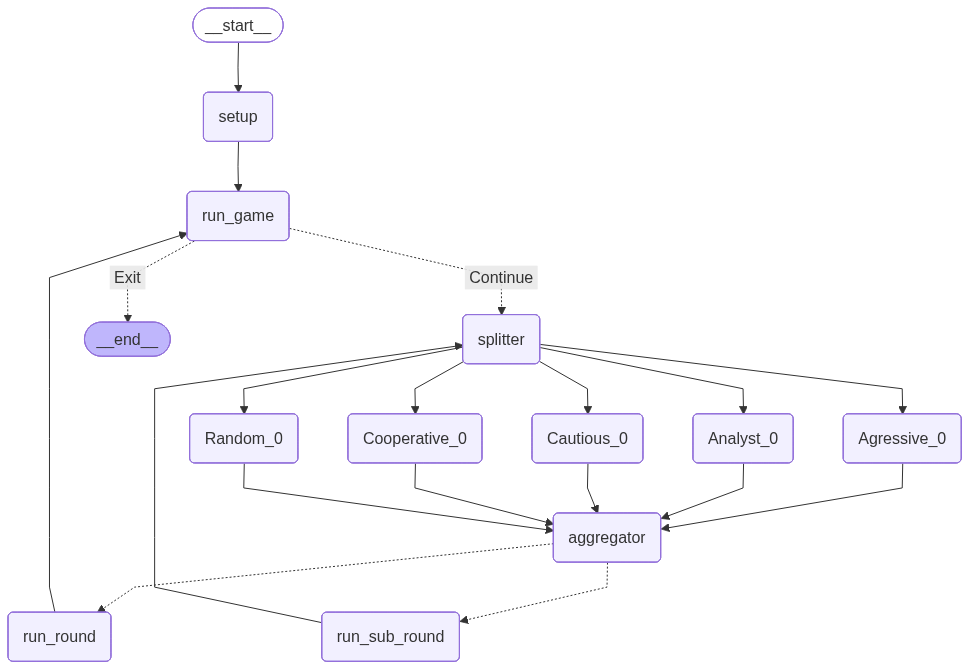

In [165]:
app=Make_Graph(5)
display (Image(app.get_graph().draw_mermaid_png()))

In [146]:
import random
def Make_Active_Players(number_of_players,seed):
    Players = ["Agressive", "Cautious", "Random", "Analyst", "Cooperative"]
    Active_player_list=[]
    for agent_number in range(number_of_players):

        agent_personality= Players[agent_number % 5]
        agent_name=f"{agent_personality}_{(agent_number)//5}"
        Active_player_list.append(agent_name)
    rng = random.Random(seed)
    rng.shuffle(Active_player_list)
    return Active_player_list


In [ ]:
Active_players=Make_Active_Players(10,7)
Active_players.index("Agressive_0")



5

In [147]:
for i in range(1):
    Active_players=Make_Active_Players(10,2+i)
    state={"Active_players" : Active_players}
    app=Make_Graph(10)
    result = app.invoke(state)
    print("\n\n\n")
    print (f"BID-HISTORY-OF-SEED-{2+i}")
    print (result["bid_history"])
    print("\n\n\n")





Round 1 begins.
Current threshold: 30.
Active players: ['Agressive_1', 'Cooperative_1', 'Analyst_0', 'Cooperative_0', 'Cautious_1', 'Random_1', 'Random_0', 'Analyst_1', 'Cautious_0', 'Agressive_0'].
Points remaining: {'Agressive_1': 500, 'Cooperative_1': 500, 'Analyst_0': 500, 'Cooperative_0': 500, 'Cautious_1': 500, 'Random_1': 500, 'Random_0': 500, 'Analyst_1': 500, 'Cautious_0': 500, 'Agressive_0': 500}.
Analyst_0 agent bid: 30 ,Confidence: 10,Reasoning-Start with the threshold to maximize survival probability and conserve points.
Cautious_1 agent bid: 25 ,Confidence: 8,Reasoning-Starting with a conservative bid to ensure survival and preserve points for future rounds.
Cooperative_0 agent bid: 20 ,Confidence: 8,Reasoning-Since it's the first round, I'll bid slightly below the threshold to be safe.
Agressive_1 agent bid: 50 ,Confidence: 8,Reasoning-I bid near the upper end of my estimated safe range to maximize my chance of survival.
Cautious_0 agent bid: 25 ,Confidence: 8,Reasonin

In [148]:
print (result["bid_history"])


{'Agressive_0': [32, 45, 90, 200, 85, 48, 0], 'Random_0': [30, 40, 50, 55, 48, 52, 50, 60, 57, 58], 'Analyst_0': [30, 32], 'Cooperative_0': [29, 40, 55, 110, 65, 48, 35, 55, 57, 6], 'Cautious_0': [25]}


In [ ]:
# N=5 Seed=0 {'Random_0': [32, 37, 40, 42, 45, 55, 52, 56, 54], 'Cautious_0': [35, 42, 55, 45, 40], 'Agressive_0': [42, 55, 90, 150, 163, 0], 'Cooperative_0': [30, 33, 37, 40, 43, 50, 52, 54, 53], 'Analyst_0': [32, 35, 40, 41, 40]}
# N=5 Seed=1 {'Random_0': [30, 35, 40, 48, 45, 78, 50, 53], 'Analyst_0': [23], 'Cooperative_0': [40, 50, 80, 60, 60, 95, 25, 48], 'Agressive_0': [43, 70, 105, 85, 75, 122, 0], 'Cautious_0': [28, 28]}
# N=5 Seed=2 {'Random_0': [27, 47, 45, 50, 55, 55, 64, 52], 'Cautious_0': [20], 'Analyst_0': [20], 'Cooperative_0': [45, 65, 50, 85, 73, 70, 25, 47], 'Agressive_0': [60, 90, 53, 110, 80, 105, 2]}
# N=5 Seed=3 {'Agressive_0': [32, 45, 90, 200, 85, 48, 0], 'Random_0': [30, 40, 50, 55, 48, 52, 50, 60, 57, 58], 'Analyst_0': [30, 32], 'Cooperative_0': [29, 40, 55, 110, 65, 48, 35, 55, 57, 6], 'Cautious_0': [25]}
# N=5 Seed=4 {'Analyst_0': [30, 40, 45, 40, 55, 50, 40], 'Cooperative_0': [45, 47, 95, 65, 80, 45, 44, 55, 24], 'Agressive_0': [70, 65, 140, 100, 120, 5], 'Random_0': [30, 35, 40, 43, 43, 40, 44, 55, 65], 'Cautious_0': [28]}
# N=5 Seed=5 {'Agressive_0': [90, 250, 97, 46, 17], 'Cautious_0': [24], 'Analyst_0': [27, 32], 'Random_0': [30, 40, 45, 43, 43, 44], 'Cooperative_0': [45, 90, 60, 43, 30, 43]}
# N=5 Seed=6 {'Analyst_0': [27, 33, 38, 45, 40], 'Random_0': [30, 35, 34], 'Cautious_0': [30, 38, 35, 42, 40], 'Agressive_0': [45, 45, 70, 100, 100], 'Cooperative_0': [26]}
# N=5 Seed=7 {'Cooperative_0': [38, 47, 60, 65, 59, 110, 20], 'Agressive_0': [60, 52, 77, 110, 65, 130, 6], 'Analyst_0': [30, 30], 'Cautious_0': [28], 'Random_0': [28]}
# N=5 Seed=8 {'Analyst_0': [43, 42, 45, 55, 50, 90, 49], 'Agressive_0': [55, 46, 60, 95, 130, 114, 0], 'Cooperative_0': [27], 'Random_0': [33, 32], 'Cautious_0': [35, 38, 41, 40, 43, 40]}
# N=5 Seed=9 {'Cooperative_0': [50, 44, 60, 70, 60, 37, 47], 'Agressive_0': [80, 45, 90, 160, 100, 25], 'Cautious_0': [26, 30], 'Random_0': [30, 43, 43, 45, 49, 42, 49], 'Analyst_0': [22]}


# N=3 Seed=0 {'Agressive_0': [27, 43, 70, 170, 95, 70, 25], 'Random_0': [27, 39, 45, 80, 48, 62, 65], 'Cautious_0': [25]}
# N=3 Seed=1 {'Cautious_0': [30, 30], 'Random_0': [38, 50, 65, 90, 50, 55], 'Agressive_0': [50, 95, 160, 120, 75, 0]}
# N=3 Seed=2 {'Cautious_0': [25], 'Random_0': [31, 40, 45, 60, 70, 85, 43], 'Agressive_0': [36, 43, 60, 150, 85, 125, 1]}
# N=3 Seed=3 {'Cautious_0': [28], 'Random_0': [38, 40, 60, 90, 50, 60], 'Agressive_0': [43, 55, 95, 190, 94, 23]}
# N=3 Seed=4 {'Random_0': [30, 38, 45, 46, 45, 52, 52, 53], 'Cautious_0': [30, 42, 55, 40, 46, 50, 45, 50], 'Agressive_0': [33, 49, 80, 130, 100, 105, 3]}
# N=3 Seed=5 {'Agressive_0': [32, 45, 90, 185, 60, 75, 13], 'Cautious_0': [29], 'Random_0': [35, 45, 42, 65, 54, 67, 45]}
# N=3 Seed=6 {'Cautious_0': [30, 38, 40, 75, 10], 'Agressive_0': [53, 85, 150, 212, 0], 'Random_0': [30, 33, 32]}
# N=3 Seed=7 {'Random_0': [38, 55, 100, 70, 43], 'Agressive_0': [80, 95, 140, 185, 0], 'Cautious_0': [28]}
# N=3 Seed=8 {'Random_0': [32, 41, 42, 50, 45, 52, 51], 'Cautious_0': [45, 50, 43, 55, 45, 49, 45], 'Agressive_0': [58, 92, 195, 95, 60, 0]}
# N=3 Seed=9 {'Agressive_0': [55, 50, 54, 85, 170, 86, 0], 'Random_0': [43, 42, 43, 45, 45, 70, 52], 'Cautious_0': [41, 42, 40, 55, 40]}


# N=10 Seed=0 {'Random_1': [28, 37, 40, 42, 40], 'Analyst_1': [27, 31, 45, 21, 40], 'Cautious_0': [35, 28], 'Agressive_1': [65, 195, 240, 0], 'Analyst_0': [25], 'Cooperative_0': [30, 35, 48, 55, 55, 55, 54, 60, 52, 56], 'Random_0': [38, 45, 60, 85, 70, 82, 60, 55, 5], 'Agressive_0': [48, 55, 90, 120, 92, 95, 0], 'Cooperative_1': [28, 32, 36, 40, 41, 50, 52, 56, 57, 57], 'Cautious_1': [28, 30, 32]}
# N=10 Seed=1 {'Cautious_1': [17], 'Analyst_1': [18, 31, 38, 39, 42, 48, 47, 53, 54, 58], 'Cooperative_1': [28, 36, 46, 45, 50, 46, 52, 52, 52], 'Random_1': [35, 45, 50, 55, 47, 47, 50, 51, 53, 59], 'Agressive_1': [47, 65, 130, 250, 8], 'Analyst_0': [25, 48, 40, 40, 55, 40, 40], 'Agressive_0': [40, 80, 170, 55, 120, 35], 'Cooperative_0': [20, 31, 33], 'Cautious_0': [22, 30, 33], 'Random_0': [20, 29]}
# N=10 Seed=2 {'Agressive_1': [65, 270, 120, 45, 0], 'Cooperative_1': [25], 'Analyst_0': [25], 'Cooperative_0': [26, 32], 'Cautious_1': [27, 32], 'Random_1': [29, 35, 38, 43, 46, 48, 53, 56, 58, 65], 'Random_0': [29, 33, 55, 80, 32, 50, 55, 58, 57, 51], 'Analyst_1': [25], 'Cautious_0': [28, 32], 'Agressive_0': [50, 120, 210, 110, 10, 0]}
# N=10 Seed=3 {'Cautious_0': [37, 42, 50, 45, 60, 49, 21, 45], 'Agressive_1': [50, 46, 70, 110, 170, 54, 0], 'Cautious_1': [40, 42, 50, 60, 45, 30, 40, 47, 50], 'Agressive_0': [90, 75, 150, 85, 90, 10], 'Cooperative_1': [26], 'Cooperative_0': [29, 33, 37, 42, 45, 46, 50, 57, 62, 63], 'Random_1': [32, 35, 38, 45, 47, 48, 52, 56, 65, 69], 'Random_0': [35, 32, 41, 45, 43, 50, 62, 50, 54, 58], 'Analyst_1': [30, 30], 'Analyst_0': [29, 30]}
# N=10 Seed=4 {'Analyst_1': [40, 41, 43, 50, 42, 45, 42], 'Random_0': [40, 45, 50, 72, 45, 45, 45, 50], 'Agressive_0': [70, 97, 245, 88, 0], 'Random_1': [28, 34, 42, 44, 47, 52, 50, 52], 'Cautious_1': [30, 32], 'Cooperative_1': [42, 65, 120, 44, 55, 48, 52, 50], 'Agressive_1': [60, 95, 170, 55, 110, 10], 'Cautious_0': [25], 'Cooperative_0': [33, 37, 40, 40, 46, 48, 49, 50], 'Analyst_0': [36, 39, 40, 43, 45, 48, 45, 50]}
# N=10 Seed=5 {'Random_0': [29, 32], 'Analyst_0': [22], 'Cautious_0': [28, 40, 40, 40, 58, 41, 40, 48, 52], 'Agressive_0': [30, 50, 105, 160, 75, 80, 0], 'Analyst_1': [28, 36, 37, 43, 42, 44, 44, 45, 50], 'Random_1': [40, 38, 42, 46, 45, 42, 43, 43], 'Cautious_1': [37, 50, 68, 60, 53, 35, 41, 43], 'Agressive_1': [60, 80, 150, 95, 85, 30], 'Cooperative_0': [26, 32], 'Cooperative_1': [27, 32]}
# N=10 Seed=6 {'Agressive_1': [55, 45, 93, 200, 100, 7], 'Analyst_1': [22], 'Analyst_0': [25, 38, 45, 47, 55, 52, 60, 60, 40, 59], 'Cooperative_0': [35, 43, 65, 100, 70, 59, 50, 52, 26], 'Agressive_0': [90, 44, 80, 135, 90, 61, 0], 'Random_0': [32, 33, 41, 45, 42, 42, 46, 54, 52, 67], 'Cautious_1': [24, 30], 'Random_1': [24, 35, 42, 37], 'Cautious_0': [28, 35, 45, 43, 45, 42, 43, 55, 55, 44], 'Cooperative_1': [40, 42, 63, 50, 62, 30, 52, 61, 56, 44]}
# N=10 Seed=7 {'Analyst_1': [29, 38, 40, 43, 40, 41], 'Analyst_0': [22], 'Cautious_0': [22], 'Cooperative_0': [30, 40, 45, 48, 42, 45, 57, 60, 55, 49], 'Random_1': [37, 46, 55, 52, 40, 58, 70, 59, 56, 27], 'Agressive_0': [48, 60, 150, 85, 87, 70, 0], 'Cooperative_1': [26, 31, 50, 50, 43, 45, 50, 57, 56, 55], 'Cautious_1': [31, 28], 'Random_0': [40, 50, 68, 80, 45, 41], 'Agressive_1': [55, 87, 150, 208, 0]}
# N=10 Seed=8 {'Analyst_1': [28, 33, 38, 43, 42, 46, 43, 55, 58, 45], 'Random_0': [28, 37, 40, 45, 47, 60, 53, 65, 60, 65], 'Cooperative_1': [30, 40, 45, 45, 48, 50, 58, 48, 51], 'Cooperative_0': [38, 43, 50, 50, 55, 60, 62, 45, 55, 42], 'Agressive_0': [45, 50, 85, 90, 80, 87, 63, 0], 'Random_1': [25, 32, 50, 44, 57, 57, 47, 58, 58, 58], 'Cautious_0': [21], 'Cautious_1': [28, 29], 'Agressive_1': [60, 55, 100, 50, 90, 110, 35], 'Analyst_0': [28, 36, 25]}
# N=10 Seed=9 {'Cooperative_1': [27, 33, 38, 38], 'Analyst_1': [29, 36, 36, 40, 42, 42], 'Analyst_0': [35, 36, 40, 43, 42, 55, 53, 50, 48, 55], 'Random_0': [40, 40, 90, 63, 62, 62, 50, 48, 45], 'Agressive_0': [45, 50, 150, 82, 110, 63, 0], 'Cautious_1': [26, 40, 45, 40, 45, 45, 42, 43], 'Cautious_0': [24], 'Cooperative_0': [30, 52, 55, 50, 48, 55, 35, 48, 50, 57], 'Agressive_1': [35, 65, 100, 150, 55, 95, 0], 'Random_1': [28, 30]}


 

In [127]:
import re
import ast

def extract_results(text):
    all_results = {}

    pattern = re.compile(r"^#\s*N=(\d+)\s+Seed=(\d+)\s+(\{.*\})$", re.MULTILINE)

    for N, seed, game in pattern.findall(text):
        N = int(N)
        seed = int(seed)

        all_results.setdefault(N, {})[seed] = ast.literal_eval(game)

    return all_results

In [148]:
text="""
# N=5 Seed=0 {'Random_0': [32, 37, 40, 42, 45, 55, 52, 56, 54], 'Cautious_0': [35, 42, 55, 45, 40], 'Agressive_0': [42, 55, 90, 150, 163, 0], 'Cooperative_0': [30, 33, 37, 40, 43, 50, 52, 54, 53], 'Analyst_0': [32, 35, 40, 41, 40]}
# N=5 Seed=1 {'Random_0': [30, 35, 40, 48, 45, 78, 50, 53], 'Analyst_0': [23], 'Cooperative_0': [40, 50, 80, 60, 60, 95, 25, 48], 'Agressive_0': [43, 70, 105, 85, 75, 122, 0], 'Cautious_0': [28, 28]}
# N=5 Seed=2 {'Random_0': [27, 47, 45, 50, 55, 55, 64, 52], 'Cautious_0': [20], 'Analyst_0': [20], 'Cooperative_0': [45, 65, 50, 85, 73, 70, 25, 47], 'Agressive_0': [60, 90, 53, 110, 80, 105, 2]}
# N=5 Seed=3 {'Agressive_0': [32, 45, 90, 200, 85, 48, 0], 'Random_0': [30, 40, 50, 55, 48, 52, 50, 60, 57, 58], 'Analyst_0': [30, 32], 'Cooperative_0': [29, 40, 55, 110, 65, 48, 35, 55, 57, 6], 'Cautious_0': [25]}
# N=5 Seed=4 {'Analyst_0': [30, 40, 45, 40, 55, 50, 40], 'Cooperative_0': [45, 47, 95, 65, 80, 45, 44, 55, 24], 'Agressive_0': [70, 65, 140, 100, 120, 5], 'Random_0': [30, 35, 40, 43, 43, 40, 44, 55, 65], 'Cautious_0': [28]}
# N=5 Seed=5 {'Agressive_0': [90, 250, 97, 46, 17], 'Cautious_0': [24], 'Analyst_0': [27, 32], 'Random_0': [30, 40, 45, 43, 43, 44], 'Cooperative_0': [45, 90, 60, 43, 30, 43]}
# N=5 Seed=6 {'Analyst_0': [27, 33, 38, 45, 40], 'Random_0': [30, 35, 34], 'Cautious_0': [30, 38, 35, 42, 40], 'Agressive_0': [45, 45, 70, 100, 100], 'Cooperative_0': [26]}
# N=5 Seed=7 {'Cooperative_0': [38, 47, 60, 65, 59, 110, 20], 'Agressive_0': [60, 52, 77, 110, 65, 130, 6], 'Analyst_0': [30, 30], 'Cautious_0': [28], 'Random_0': [28]}
# N=5 Seed=8 {'Analyst_0': [43, 42, 45, 55, 50, 90, 49], 'Agressive_0': [55, 46, 60, 95, 130, 114, 0], 'Cooperative_0': [27], 'Random_0': [33, 32], 'Cautious_0': [35, 38, 41, 40, 43, 40]}
# N=5 Seed=9 {'Cooperative_0': [50, 44, 60, 70, 60, 37, 47], 'Agressive_0': [80, 45, 90, 160, 100, 25], 'Cautious_0': [26, 30], 'Random_0': [30, 43, 43, 45, 49, 42, 49], 'Analyst_0': [22]}


# N=3 Seed=0 {'Agressive_0': [27, 43, 70, 170, 95, 70, 25], 'Random_0': [27, 39, 45, 80, 48, 62, 65], 'Cautious_0': [25]}
# N=3 Seed=1 {'Cautious_0': [30, 30], 'Random_0': [38, 50, 65, 90, 50, 55], 'Agressive_0': [50, 95, 160, 120, 75, 0]}
# N=3 Seed=2 {'Cautious_0': [25], 'Random_0': [31, 40, 45, 60, 70, 85, 43], 'Agressive_0': [36, 43, 60, 150, 85, 125, 1]}
# N=3 Seed=3 {'Cautious_0': [28], 'Random_0': [38, 40, 60, 90, 50, 60], 'Agressive_0': [43, 55, 95, 190, 94, 23]}
# N=3 Seed=4 {'Random_0': [30, 38, 45, 46, 45, 52, 52, 53], 'Cautious_0': [30, 42, 55, 40, 46, 50, 45, 50], 'Agressive_0': [33, 49, 80, 130, 100, 105, 3]}
# N=3 Seed=5 {'Agressive_0': [32, 45, 90, 185, 60, 75, 13], 'Cautious_0': [29], 'Random_0': [35, 45, 42, 65, 54, 67, 45]}
# N=3 Seed=6 {'Cautious_0': [30, 38, 40, 75, 10], 'Agressive_0': [53, 85, 150, 212, 0], 'Random_0': [30, 33, 32]}
# N=3 Seed=7 {'Random_0': [38, 55, 100, 70, 43], 'Agressive_0': [80, 95, 140, 185, 0], 'Cautious_0': [28]}
# N=3 Seed=8 {'Random_0': [32, 41, 42, 50, 45, 52, 51], 'Cautious_0': [45, 50, 43, 55, 45, 49, 45], 'Agressive_0': [58, 92, 195, 95, 60, 0]}
# N=3 Seed=9 {'Agressive_0': [55, 50, 54, 85, 170, 86, 0], 'Random_0': [43, 42, 43, 45, 45, 70, 52], 'Cautious_0': [41, 42, 40, 55, 40]}


# N=10 Seed=0 {'Random_1': [28, 37, 40, 42, 40], 'Analyst_1': [27, 31, 45, 21, 40], 'Cautious_0': [35, 28], 'Agressive_1': [65, 195, 240, 0], 'Analyst_0': [25], 'Cooperative_0': [30, 35, 48, 55, 55, 55, 54, 60, 52, 56], 'Random_0': [38, 45, 60, 85, 70, 82, 60, 55, 5], 'Agressive_0': [48, 55, 90, 120, 92, 95, 0], 'Cooperative_1': [28, 32, 36, 40, 41, 50, 52, 56, 57, 57], 'Cautious_1': [28, 30, 32]}
# N=10 Seed=1 {'Cautious_1': [17], 'Analyst_1': [18, 31, 38, 39, 42, 48, 47, 53, 54, 58], 'Cooperative_1': [28, 36, 46, 45, 50, 46, 52, 52, 52], 'Random_1': [35, 45, 50, 55, 47, 47, 50, 51, 53, 59], 'Agressive_1': [47, 65, 130, 250, 8], 'Analyst_0': [25, 48, 40, 40, 55, 40, 40], 'Agressive_0': [40, 80, 170, 55, 120, 35], 'Cooperative_0': [20, 31, 33], 'Cautious_0': [22, 30, 33], 'Random_0': [20, 29]}
# N=10 Seed=2 {'Agressive_1': [65, 270, 120, 45, 0], 'Cooperative_1': [25], 'Analyst_0': [25], 'Cooperative_0': [26, 32], 'Cautious_1': [27, 32], 'Random_1': [29, 35, 38, 43, 46, 48, 53, 56, 58, 65], 'Random_0': [29, 33, 55, 80, 32, 50, 55, 58, 57, 51], 'Analyst_1': [25], 'Cautious_0': [28, 32], 'Agressive_0': [50, 120, 210, 110, 10, 0]}

# N=10 Seed=3 {'Cautious_0': [37, 42, 50, 45, 60, 49, 21, 45], 'Agressive_1': [50, 46, 70, 110, 170, 54, 0], 'Cautious_1': [40, 42, 50, 60, 45, 30, 40, 47, 50], 'Agressive_0': [90, 75, 150, 85, 90, 10], 'Cooperative_1': [26], 'Cooperative_0': [29, 33, 37, 42, 45, 46, 50, 57, 62, 63], 'Random_1': [32, 35, 38, 45, 47, 48, 52, 56, 65, 69], 'Random_0': [35, 32, 41, 45, 43, 50, 62, 50, 54, 58], 'Analyst_1': [30, 30], 'Analyst_0': [29, 30]}
# N=10 Seed=4 {'Analyst_1': [40, 41, 43, 50, 42, 45, 42], 'Random_0': [40, 45, 50, 72, 45, 45, 45, 50], 'Agressive_0': [70, 97, 245, 88, 0], 'Random_1': [28, 34, 42, 44, 47, 52, 50, 52], 'Cautious_1': [30, 32], 'Cooperative_1': [42, 65, 120, 44, 55, 48, 52, 50], 'Agressive_1': [60, 95, 170, 55, 110, 10], 'Cautious_0': [25], 'Cooperative_0': [33, 37, 40, 40, 46, 48, 49, 50], 'Analyst_0': [36, 39, 40, 43, 45, 48, 45, 50]}
# N=10 Seed=5 {'Random_0': [29, 32], 'Analyst_0': [22], 'Cautious_0': [28, 40, 40, 40, 58, 41, 40, 48, 52], 'Agressive_0': [30, 50, 105, 160, 75, 80, 0], 'Analyst_1': [28, 36, 37, 43, 42, 44, 44, 45, 50], 'Random_1': [40, 38, 42, 46, 45, 42, 43, 43], 'Cautious_1': [37, 50, 68, 60, 53, 35, 41, 43], 'Agressive_1': [60, 80, 150, 95, 85, 30], 'Cooperative_0': [26, 32], 'Cooperative_1': [27, 32]}
# N=10 Seed=6 {'Agressive_1': [55, 45, 93, 200, 100, 7], 'Analyst_1': [22], 'Analyst_0': [25, 38, 45, 47, 55, 52, 60, 60, 40, 59], 'Cooperative_0': [35, 43, 65, 100, 70, 59, 50, 52, 26], 'Agressive_0': [90, 44, 80, 135, 90, 61, 0], 'Random_0': [32, 33, 41, 45, 42, 42, 46, 54, 52, 67], 'Cautious_1': [24, 30], 'Random_1': [24, 35, 42, 37], 'Cautious_0': [28, 35, 45, 43, 45, 42, 43, 55, 55, 44], 'Cooperative_1': [40, 42, 63, 50, 62, 30, 52, 61, 56, 44]}
# N=10 Seed=7 {'Analyst_1': [29, 38, 40, 43, 40, 41], 'Analyst_0': [22], 'Cautious_0': [22], 'Cooperative_0': [30, 40, 45, 48, 42, 45, 57, 60, 55, 49], 'Random_1': [37, 46, 55, 52, 40, 58, 70, 59, 56, 27], 'Agressive_0': [48, 60, 150, 85, 87, 70, 0], 'Cooperative_1': [26, 31, 50, 50, 43, 45, 50, 57, 56, 55], 'Cautious_1': [31, 28], 'Random_0': [40, 50, 68, 80, 45, 41], 'Agressive_1': [55, 87, 150, 208, 0]}
# N=10 Seed=8 {'Analyst_1': [28, 33, 38, 43, 42, 46, 43, 55, 58, 45], 'Random_0': [28, 37, 40, 45, 47, 60, 53, 65, 60, 65], 'Cooperative_1': [30, 40, 45, 45, 48, 50, 58, 48, 51], 'Cooperative_0': [38, 43, 50, 50, 55, 60, 62, 45, 55, 42], 'Agressive_0': [45, 50, 85, 90, 80, 87, 63, 0], 'Random_1': [25, 32, 50, 44, 57, 57, 47, 58, 58, 58], 'Cautious_0': [21], 'Cautious_1': [28, 29], 'Agressive_1': [60, 55, 100, 50, 90, 110, 35], 'Analyst_0': [28, 36, 25]}
# N=10 Seed=9 {'Cooperative_1': [27, 33, 38, 38], 'Analyst_1': [29, 36, 36, 40, 42, 42], 'Analyst_0': [35, 36, 40, 43, 42, 55, 53, 50, 48, 55], 'Random_0': [40, 40, 90, 63, 62, 62, 50, 48, 45], 'Agressive_0': [45, 50, 150, 82, 110, 63, 0], 'Cautious_1': [26, 40, 45, 40, 45, 45, 42, 43], 'Cautious_0': [24], 'Cooperative_0': [30, 52, 55, 50, 48, 55, 35, 48, 50, 57], 'Agressive_1': [35, 65, 100, 150, 55, 95, 0], 'Random_1': [28, 30]}
"""
All_Results=extract_results(text)

In [149]:
import numpy as np
def consensus_per_round_for_one_game(game):

    max_rounds = max(len(v) for v in game.values())
    consensus = []
    for r in range(max_rounds):
        bids = []
        
        for history in game.values():
            if r < len(history):
                bids.append(history[r])

        consensus.append(round(np.mean(bids)))

    return consensus

def threshold(round_number):
    return 30 + 3*(round_number) #Because when we enumertae we start with index 0, so no need to add -1 to round no 

def trial_accuracy_for_one_game(consensus):

    accuracies = []

    for r,bid in enumerate(consensus):

        accuracies.append(int(bid >= threshold(r)))

    return np.mean(accuracies)


In [150]:
len(All_Results[3])

10

In [151]:
def statistics_for_N(results_for_N):

    trial_accuracies_for_one_seed_across_one_n = []
    final_consensus = []
    consensus_histories = []

    for seed,game in results_for_N.items():

        consensus = consensus_per_round_for_one_game(game)

        consensus_histories.append(consensus)

        trial_accuracies_for_one_seed_across_one_n.append(
            trial_accuracy_for_one_game(consensus)
        )
        final_consensus.append(consensus[-1])
        # last played round instead of round 10
        # if len(game)==3:
        #     if len(consensus)>=7:
        #         final_consensus.append(consensus[6])
        # elif len(game)==5:
        #     if len(consensus)>=9:
        #         final_consensus.append(consensus[8])
        # else :
        #     if len(consensus)==10:
        #         final_consensus.append(consensus[9])

    return {
        "mean_accuracy":np.mean(trial_accuracies_for_one_seed_across_one_n),
        "std_accuracy":np.std(trial_accuracies_for_one_seed_across_one_n),
        "bid_variance":np.var(final_consensus),
        "trial_accuracies":trial_accuracies_for_one_seed_across_one_n,
        "final_consensus":final_consensus,
        "consensus_histories":consensus_histories
    }

In [152]:
from scipy.stats import entropy

def entropy_per_round(game):

    entropies = []

    max_rounds = max(len(v) for v in game.values())

    for r in range(max_rounds):

        bids = []

        for history in game.values():

            if r < len(history):
                bids.append(round(history[r]))

        counts = np.bincount(bids)

        entropies.append(entropy(counts + 1e-9))

    return entropies

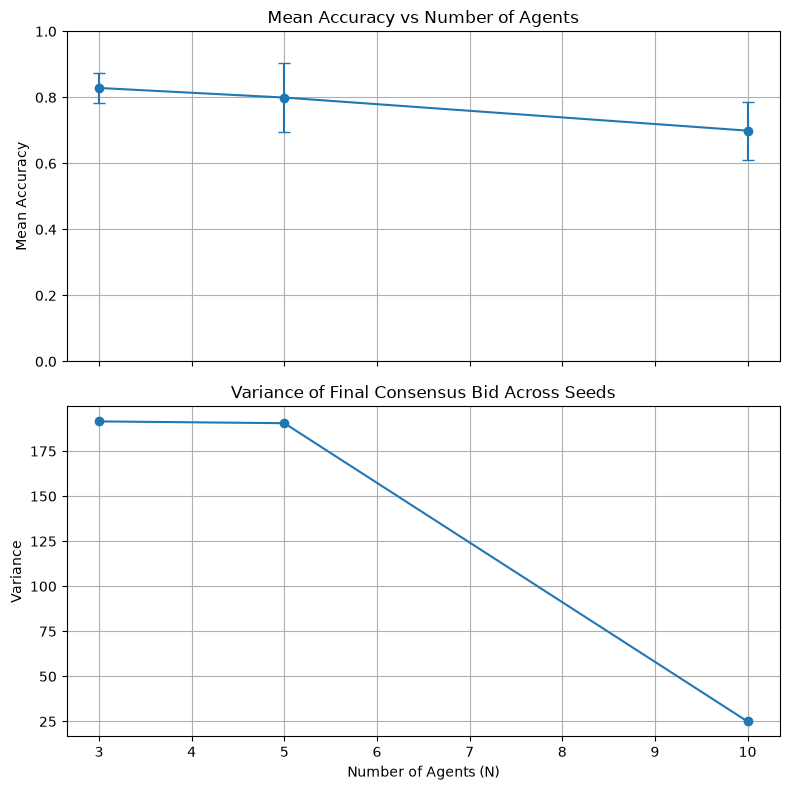

In [153]:
import matplotlib.pyplot as plt
Statistics_3=statistics_for_N(All_Results[3])
Statistics_5=statistics_for_N(All_Results[5])
Statistics_10=statistics_for_N(All_Results[10])
Statistics=[Statistics_3,Statistics_5,Statistics_10]


mean_accuracy=[]
std_accuracy=[]
bid_variance=[]
for Stats_N in Statistics:
    mean_accuracy.append(Stats_N["mean_accuracy"])
    std_accuracy.append(Stats_N["std_accuracy"])
    bid_variance.append(Stats_N["bid_variance"])
    
N_values=[3,5,10]

fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(8, 8),sharex=True)

ax1.errorbar(N_values, mean_accuracy, yerr=std_accuracy, fmt='-o', capsize=4)
ax1.set_ylabel("Mean Accuracy")
ax1.set_ylim(0, 1)
ax1.set_title("Mean Accuracy vs Number of Agents")
ax1.grid(True)

ax2.plot(N_values,bid_variance,'-o')

ax2.set_xlabel("Number of Agents (N)")
ax2.set_ylabel("Variance")
ax2.set_title("Variance of Final Consensus Bid Across Seeds")
ax2.grid(True)

plt.tight_layout()
plt.savefig("drift_selection_plot.png", dpi=300)
plt.show()


c:\Users\bhaga\OneDrive\Desktop\Minerva Week4\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\bhaga\OneDrive\Desktop\Minerva Week4\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


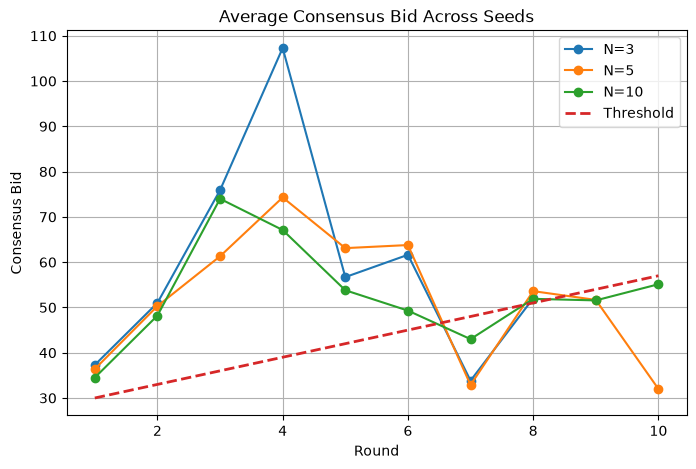

In [154]:
# consensus_histories

thresholds = [30 + 3*i for i in range(10)]

plt.figure(figsize=(8,5))

for N in [3,5,10]:
    Stats = statistics_for_N(All_Results[N])
    consensus =Stats["consensus_histories"]
    # Average consensus for each round
    mean_consensus = []

    for r in range(10):
        bids = []
        for seed in consensus:
            if r < len(seed):           # Game may have ended early
                bids.append(seed[r])

        mean_consensus.append(np.mean(bids))

    plt.plot(range(1,11), mean_consensus, marker='o', label=f'N={N}')

plt.plot(range(1,11), thresholds,
         '--', linewidth=2, label='Threshold')

plt.xlabel("Round")
plt.ylabel("Consensus Bid")
plt.title("Average Consensus Bid Across Seeds")
plt.legend()
plt.grid(True)
plt.savefig("Graphs\\Average Consensus Bid Across Seeds", dpi=300)
plt.show()


10


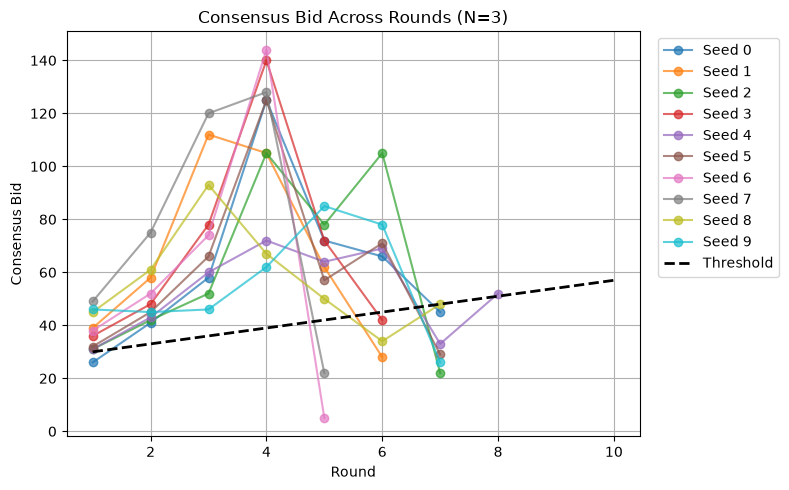

10


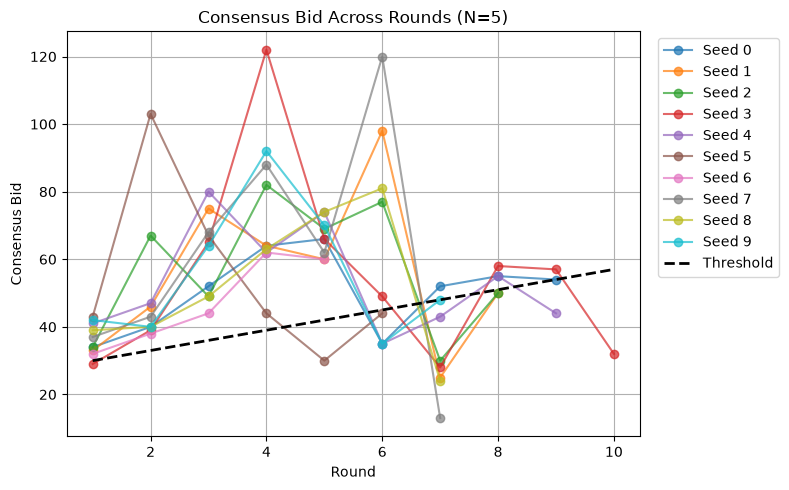

10


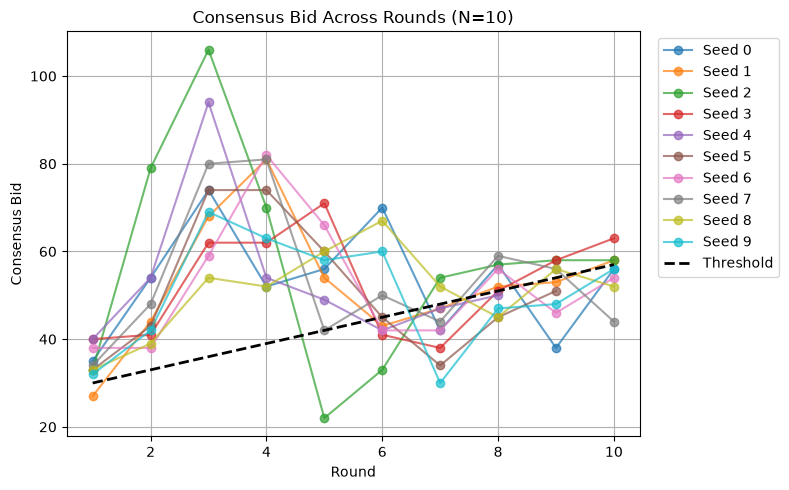

In [155]:
thresholds = [30 + 3*i for i in range(10)]

for N in [3, 5, 10]:

    plt.figure(figsize=(8,5))

    Stats = statistics_for_N(All_Results[N])
    consensus_per_seed = Stats["consensus_histories"]
    print (len(consensus_per_seed))
    # Plot every seed
    for seed, consensus in enumerate(consensus_per_seed):
        rounds = range(1, len(consensus)+1)

        plt.plot(
            rounds,
            consensus,
            marker='o',
            linewidth=1.5,
            alpha=0.7,
            label=f"Seed {seed}"
        )
        plt.legend()

    # Plot threshold
    plt.plot(
        range(1,11),
        thresholds,
        'k--',
        linewidth=2,
        label="Threshold"
    )

    plt.title(f"Consensus Bid Across Rounds (N={N})")
    plt.xlabel("Round")
    plt.ylabel("Consensus Bid")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

    plt.tight_layout()
    plt.savefig(f"Graphs\\Consensus Bids of each seed\\For N={N}.png", dpi=300)
    
    plt.show()

c:\Users\bhaga\OneDrive\Desktop\Minerva Week4\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\bhaga\OneDrive\Desktop\Minerva Week4\.venv\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\bhaga\OneDrive\Desktop\Minerva Week4\.venv\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


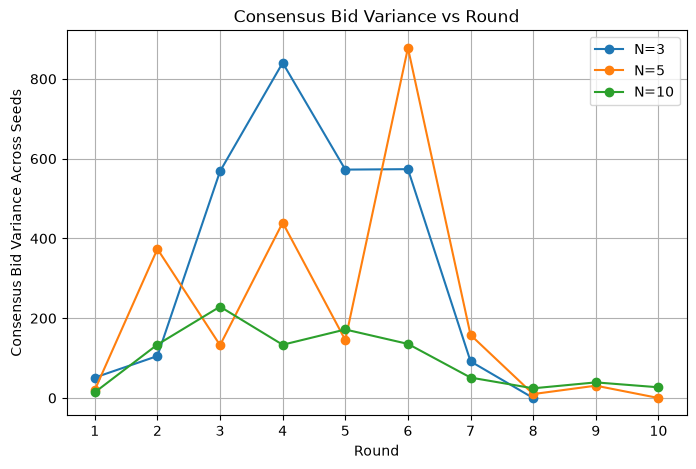

In [156]:

plt.figure(figsize=(8,5))

for N in [3, 5, 10]:
    consensus_history = statistics_for_N(All_Results[N])["consensus_histories"]

    variance = [
        np.var([seed[r] for seed in consensus_history if r < len(seed)])
        for r in range(10)
    ]

    plt.plot(range(1, 11), variance, marker='o', label=f"N={N}")

plt.xlabel("Round")
plt.ylabel("Consensus Bid Variance Across Seeds")
plt.title("Consensus Bid Variance vs Round")
plt.xticks(range(1, 11))
plt.grid(True)
plt.legend()
plt.savefig("Graphs\\Bid Variance Plot.png", dpi=300)

plt.show()

In [ ]:
"""
To plot
1.main results all seeds combined mean,std accuracy and  bid_variance
2.Consensus bid, 3 Horizontally placed graphs for each N but containing all seeds and all rounds from them along with threshold
3.Optional(Average across seeds consensus graph per round of all 3 on same graph)
4. Mean Accuracies for different seeds for all 3 N plotted on same graph
5.Bid Variance for each round
"""